# Customer Churn Prediction

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stat
import pylab

import mysql.connector
from config import DB_CONFIG

In [2]:
df = pd.read_excel("../dataset/E Commerce Dataset.xlsx", sheet_name = "E Comm")

In [3]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [4]:
df.tail()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
5625,55626,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,2.0,4.0,150.71
5626,55627,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,NaN,224.91
5627,55628,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186.42
5628,55629,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,2.0,9.0,178.90
5629,55630,0,8.0,Mobile Phone,1,15.0,Credit Card,Male,3.0,2,Laptop & Accessory,3,Married,4,0,13.0,2.0,2.0,3.0,169.04


In [5]:
df["Tenure"].nunique()

36

In [6]:
print("rows :",df.shape[0])
print("columns :",df.shape[1])

rows : 5630
columns : 20


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,5630.0,52815.500000,1625.385339,50001.0,51408.25,52815.50,54222.7500,55630.00
Churn,5630.0,0.168384,0.374240,0.0,0.00,0.00,0.0000,1.00
Tenure,5366.0,10.189899,8.557241,0.0,2.00,9.00,16.0000,61.00
CityTier,5630.0,1.654707,0.915389,1.0,1.00,1.00,3.0000,3.00
WarehouseToHome,5379.0,15.639896,8.531475,5.0,9.00,14.00,20.0000,127.00
HourSpendOnApp,5375.0,2.931535,0.721926,0.0,2.00,3.00,3.0000,5.00
NumberOfDeviceRegistered,5630.0,3.688988,1.023999,1.0,3.00,4.00,4.0000,6.00
SatisfactionScore,5630.0,3.066785,1.380194,1.0,2.00,3.00,4.0000,5.00
NumberOfAddress,5630.0,4.214032,2.583586,1.0,2.00,3.00,6.0000,22.00
Complain,5630.0,0.284902,0.451408,0.0,0.00,0.00,1.0000,1.00


In [9]:
df.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.value_counts("Gender")

Gender
Male      3384
Female    2246
Name: count, dtype: int64

In [12]:
df["Gender"].nunique()

2

In [13]:
df.isnull().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [14]:
sns.set_style('whitegrid')

In [15]:
def plot_data(sample,img):
    plt.figure(figsize = (10,6))
    plt.subplot(1,2,1)
    sns.histplot(sample.dropna(), kde = True)
    plt.subplot(1,2,2)
    stat.probplot(sample.dropna(),dist = "norm", plot = pylab)
    plt.savefig(f'../eda/{img}.png', dpi=120, bbox_inches='tight')
    plt.show()

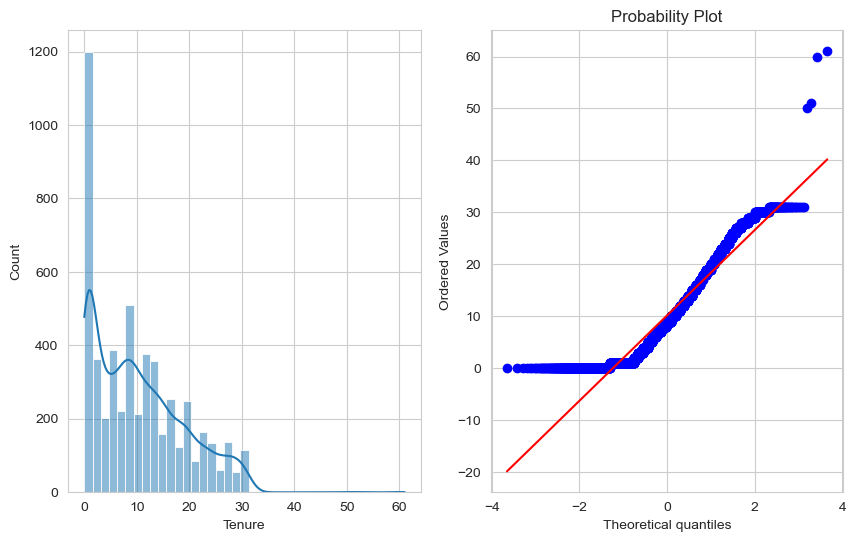

In [16]:
plot_data(df["Tenure"],"tenure")

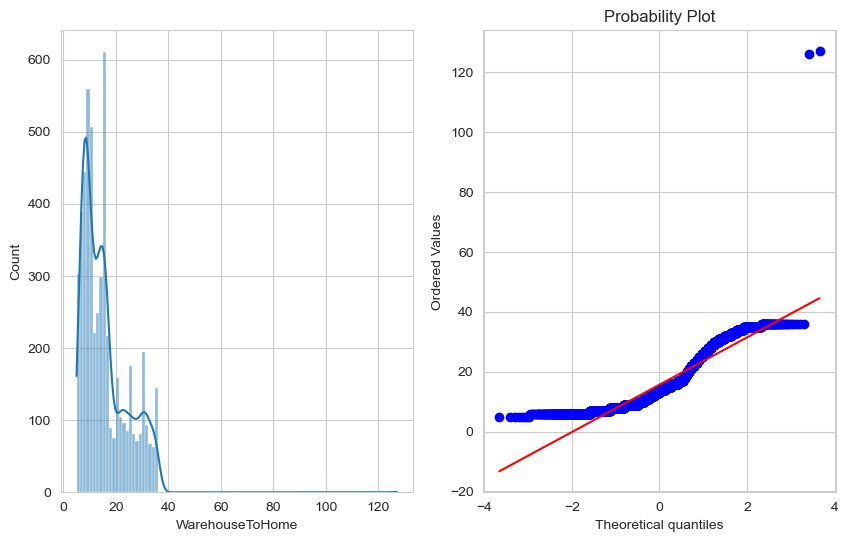

In [17]:
plot_data(df["WarehouseToHome"],"warehousetohome")

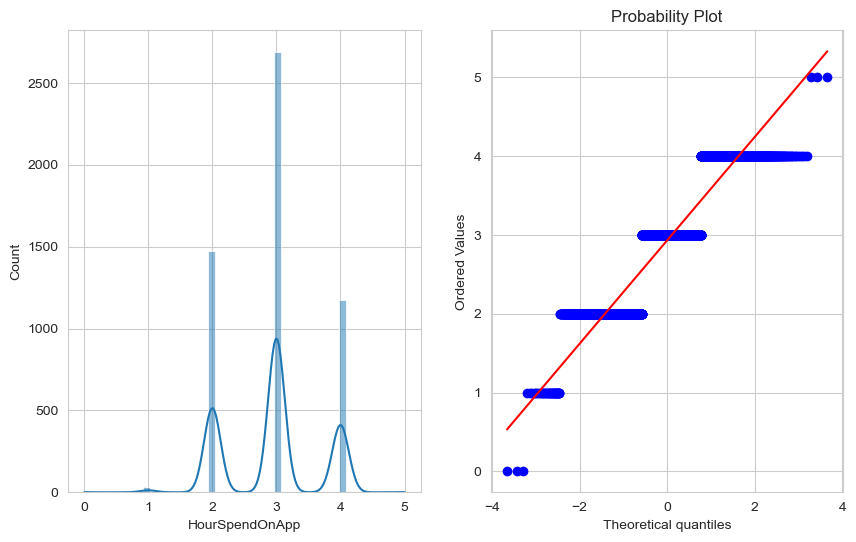

In [18]:
plot_data(df["HourSpendOnApp"],"hourspendonapp")

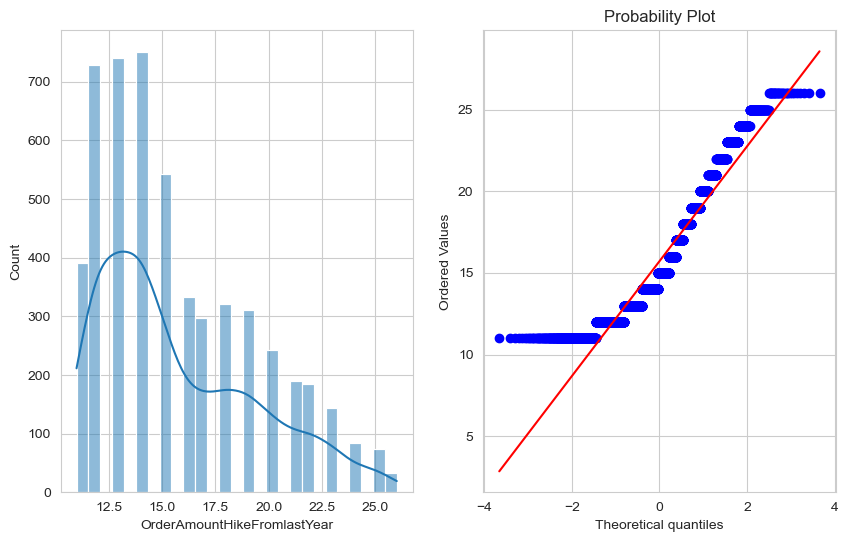

In [19]:
plot_data(df["OrderAmountHikeFromlastYear"],"orderamounthikefromlastyear")

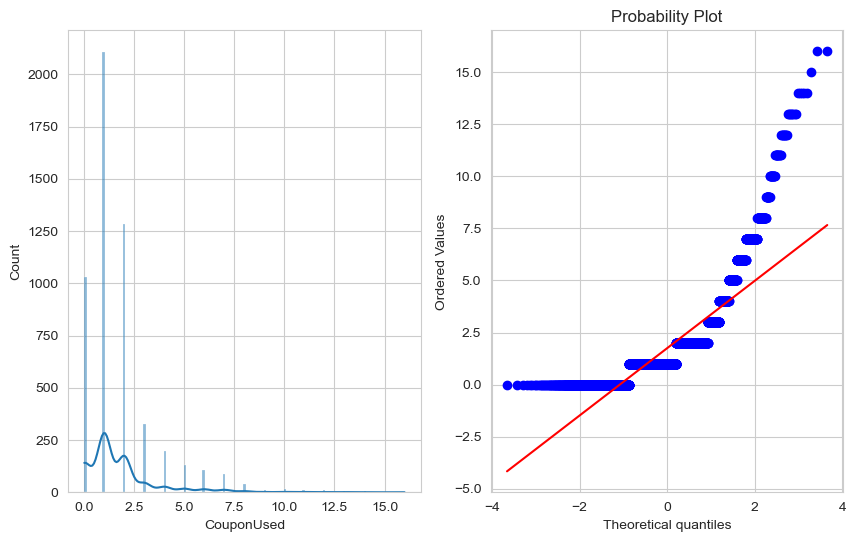

In [20]:
plot_data(df["CouponUsed"], "couponused")

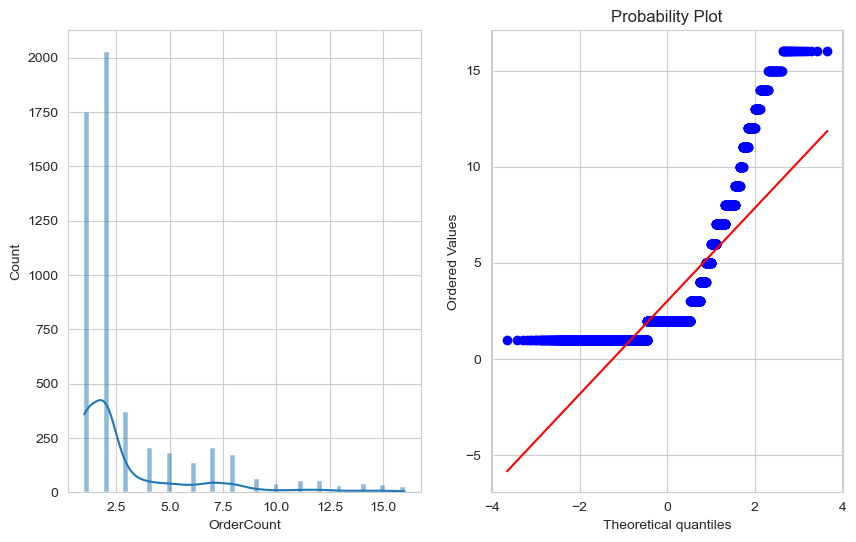

In [21]:
plot_data(df["OrderCount"],"ordercount")

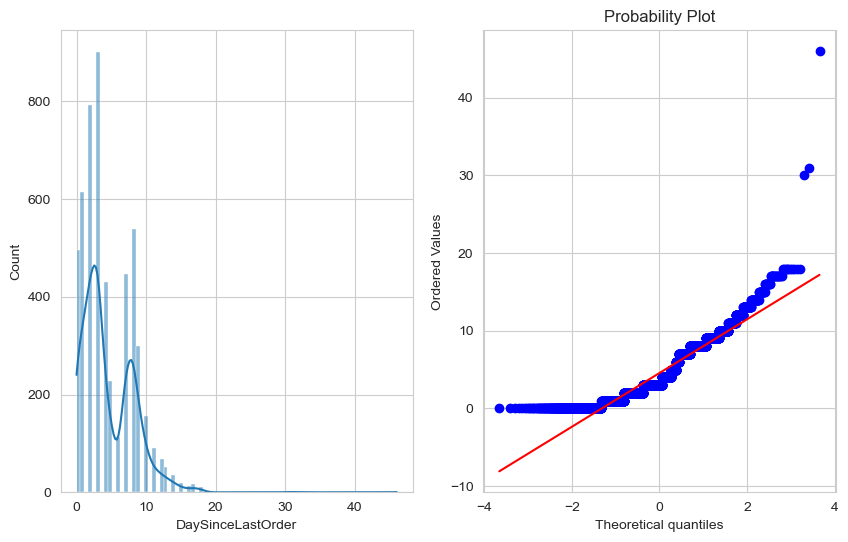

In [22]:
plot_data(df["DaySinceLastOrder"],"daysincelastorder")

In [23]:
print("Skewness")
print("Tenure :",round(df["Tenure"].skew(),2))
print("WarehouseToHome :",round(df["WarehouseToHome"].skew(),2))
print("HourSpendOnApp :",round(df["HourSpendOnApp"].skew(),2))
print("OrderAmountHikeFromlastYear :",round(df["OrderAmountHikeFromlastYear"].skew(),2))
print("CouponUsed :",round(df["CouponUsed"].skew(),2))
print("OrderCount :",round(df["OrderCount"].skew(),2))
print("DaySinceLastOrder :",round(df["DaySinceLastOrder"].skew(),2))
print("-"*50)
print("Skewness with Churn Groupby")
print("Tenure :",round(df.groupby('Churn')["Tenure"].skew(),2))
print("WarehouseToHome :",round(df.groupby('Churn')["WarehouseToHome"].skew(),2))
print("HourSpendOnApp :",round(df.groupby('Churn')["HourSpendOnApp"].skew(),2))
print("OrderAmountHikeFromlastYear :",round(df.groupby('Churn')["OrderAmountHikeFromlastYear"].skew(),2))
print("CouponUsed :",round(df.groupby('Churn')["CouponUsed"].skew(),2))
print("OrderCount :",round(df.groupby('Churn')["OrderCount"].skew(),2))
print("DaySinceLastOrder :",round(df.groupby('Churn')["DaySinceLastOrder"].skew(),2))

Skewness
Tenure : 0.74
WarehouseToHome : 1.62
HourSpendOnApp : -0.03
OrderAmountHikeFromlastYear : 0.79
CouponUsed : 2.55
OrderCount : 2.2
DaySinceLastOrder : 1.19
--------------------------------------------------
Skewness with Churn Groupby
Tenure : Churn
0    0.65
1    1.89
Name: Tenure, dtype: float64
WarehouseToHome : Churn
0    1.84
1    0.60
Name: WarehouseToHome, dtype: float64
HourSpendOnApp : Churn
0   -0.04
1    0.05
Name: HourSpendOnApp, dtype: float64
OrderAmountHikeFromlastYear : Churn
0    0.79
1    0.82
Name: OrderAmountHikeFromlastYear, dtype: float64
CouponUsed : Churn
0    2.53
1    2.62
Name: CouponUsed, dtype: float64
OrderCount : Churn
0    2.15
1    2.47
Name: OrderCount, dtype: float64
DaySinceLastOrder : Churn
0    0.93
1    3.00
Name: DaySinceLastOrder, dtype: float64


In [24]:
col = "WarehouseToHome"

def get_iqr_bounds(series):
    """Calculate IQR-based lower and upper bounds, ignoring NaNs."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

# Step 1: Inspect outliers before touching anything

lower, upper = get_iqr_bounds(df[col])
lower = 0
outliers = df[(df[col] < lower) | (df[col] > upper)]
print(f"\n{col}: bounds = ({lower:.2f}, {upper:.2f})")
print(f"  Outlier count: {outliers.shape[0]}")
print(f"  Outlier values: {sorted(outliers[col].dropna().unique())}")


WarehouseToHome: bounds = (0.00, 36.50)
  Outlier count: 2
  Outlier values: [np.float64(126.0), np.float64(127.0)]


In [25]:
# Remove the 2 outlier rows in WarehouseToHome (126 and 127)
df = df[~df['WarehouseToHome'].isin([126, 127])].reset_index(drop=True)

print("Rows after removal:", df.shape[0])

Rows after removal: 5628


In [26]:
print("Missing values before imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values before imputation:
Tenure                         264
WarehouseToHome                251
HourSpendOnApp                 255
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
dtype: int64


In [27]:
# --- Group-wise median imputation (by Churn) ---
group_median_cols = ['Tenure', 'WarehouseToHome', 'DaySinceLastOrder']

for col in group_median_cols:
    df[col] = df.groupby('Churn')[col].transform(lambda x: x.fillna(x.median()))

# --- Global median imputation ---
global_median_cols = ['OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount']

for col in global_median_cols:
    df[col] = df[col].fillna(df[col].median())

# --- Mode imputation ---
df['HourSpendOnApp'] = df['HourSpendOnApp'].fillna(df['HourSpendOnApp'].mode()[0])

print("\nMissing values after imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else "None — all filled.")


Missing values after imputation:
None — all filled.


In [28]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,1.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,1.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [29]:
df["PreferredPaymentMode"].unique()

array(['Debit Card', 'UPI', 'CC', 'Cash on Delivery', 'E wallet', 'COD',
       'Credit Card'], dtype=object)

In [30]:
payment_map = {
    "CC" : "Credit Card",
    "COD" : "Cash on Delivery"
}

df["PreferredPaymentMode"] = df["PreferredPaymentMode"].replace(payment_map)

In [31]:
df["PreferredPaymentMode"].unique()

array(['Debit Card', 'UPI', 'Credit Card', 'Cash on Delivery', 'E wallet'],
      dtype=object)

In [32]:
df["PreferredPaymentMode"].value_counts()

PreferredPaymentMode
Debit Card          2312
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64

In [33]:
df["PreferredLoginDevice"].unique()

array(['Mobile Phone', 'Phone', 'Computer'], dtype=object)

In [34]:
device_map = {
    "Phone" : "Mobile Phone"
}

df["PreferredLoginDevice"] = df["PreferredLoginDevice"].replace(device_map)

In [35]:
df["PreferredLoginDevice"].unique()

array(['Mobile Phone', 'Computer'], dtype=object)

In [36]:
df["PreferredLoginDevice"].value_counts()

PreferredLoginDevice
Mobile Phone    3996
Computer        1632
Name: count, dtype: int64

In [37]:
df["Gender"].unique()

array(['Female', 'Male'], dtype=object)

In [38]:
df["PreferedOrderCat"].unique()

array(['Laptop & Accessory', 'Mobile', 'Mobile Phone', 'Others',
       'Fashion', 'Grocery'], dtype=object)

In [39]:
order_map = {
    "Mobile" : "Mobile Phone"
}

df["PreferedOrderCat"] = df["PreferedOrderCat"].replace(order_map)

In [40]:
df["PreferedOrderCat"].unique()

array(['Laptop & Accessory', 'Mobile Phone', 'Others', 'Fashion',
       'Grocery'], dtype=object)

In [41]:
df["PreferedOrderCat"].value_counts()

PreferedOrderCat
Mobile Phone          2078
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264
Name: count, dtype: int64

In [42]:
df["MaritalStatus"].unique()

array(['Single', 'Divorced', 'Married'], dtype=object)

In [43]:
df = df.rename(columns= {"PreferedOrderCat" : "PreferredOrderCat"})

In [44]:
df.columns.tolist()

['CustomerID',
 'Churn',
 'Tenure',
 'PreferredLoginDevice',
 'CityTier',
 'WarehouseToHome',
 'PreferredPaymentMode',
 'Gender',
 'HourSpendOnApp',
 'NumberOfDeviceRegistered',
 'PreferredOrderCat',
 'SatisfactionScore',
 'MaritalStatus',
 'NumberOfAddress',
 'Complain',
 'OrderAmountHikeFromlastYear',
 'CouponUsed',
 'OrderCount',
 'DaySinceLastOrder',
 'CashbackAmount']

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5628 entries, 0 to 5627
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5628 non-null   int64  
 1   Churn                        5628 non-null   int64  
 2   Tenure                       5628 non-null   float64
 3   PreferredLoginDevice         5628 non-null   object 
 4   CityTier                     5628 non-null   int64  
 5   WarehouseToHome              5628 non-null   float64
 6   PreferredPaymentMode         5628 non-null   object 
 7   Gender                       5628 non-null   object 
 8   HourSpendOnApp               5628 non-null   float64
 9   NumberOfDeviceRegistered     5628 non-null   int64  
 10  PreferredOrderCat            5628 non-null   object 
 11  SatisfactionScore            5628 non-null   int64  
 12  MaritalStatus                5628 non-null   object 
 13  NumberOfAddress   

In [46]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,5628.0,52815.534826,1625.456539,50001.0,51408.75,52815.50,54223.25,55630.00
Churn,5628.0,0.168443,0.374293,0.0,0.00,0.00,0.00,1.00
Tenure,5628.0,10.046020,8.421974,0.0,2.00,9.00,15.00,61.00
CityTier,5628.0,1.654229,0.915200,1.0,1.00,1.00,3.00,3.00
WarehouseToHome,5628.0,15.512615,8.086634,5.0,9.00,13.00,20.00,36.00
HourSpendOnApp,5628.0,2.934790,0.705543,0.0,2.00,3.00,3.00,5.00
NumberOfDeviceRegistered,5628.0,3.689055,1.024131,1.0,3.00,4.00,4.00,6.00
SatisfactionScore,5628.0,3.067520,1.379889,1.0,2.00,3.00,4.00,5.00
NumberOfAddress,5628.0,4.214286,2.583992,1.0,2.00,3.00,6.00,22.00
Complain,5628.0,0.285004,0.451456,0.0,0.00,0.00,1.00,1.00


In [47]:
# Nominal categorical columns
nominal_cols = ['PreferredPaymentMode', 'PreferredLoginDevice', 'PreferredOrderCat',
                'MaritalStatus', 'Gender']

for col in nominal_cols:
    df[col] = df[col].astype('category')

# Ordinal/discrete categorical columns (bounded, meaningful order or limited levels)
ordinal_cols = ['CityTier', 'SatisfactionScore', 'NumberOfDeviceRegistered', 'NumberOfAddress']

for col in ordinal_cols:
    df[col] = df[col].astype('category')

# Binary flag columns
binary_cols = ['Churn', 'Complain']

for col in binary_cols:
    df[col] = df[col].astype('bool')

print(df.dtypes)

CustomerID                        int64
Churn                              bool
Tenure                          float64
PreferredLoginDevice           category
CityTier                       category
WarehouseToHome                 float64
PreferredPaymentMode           category
Gender                         category
HourSpendOnApp                  float64
NumberOfDeviceRegistered       category
PreferredOrderCat              category
SatisfactionScore              category
MaritalStatus                  category
NumberOfAddress                category
Complain                           bool
OrderAmountHikeFromlastYear     float64
CouponUsed                      float64
OrderCount                      float64
DaySinceLastOrder               float64
CashbackAmount                  float64
dtype: object


In [48]:
discrete_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                  'OrderAmountHikeFromlastYear', 'CouponUsed',
                  'OrderCount', 'DaySinceLastOrder']

# Check for any non-whole-number values first (possible from group-wise median)
for col in discrete_cols:
    non_whole = df[~(df[col] == df[col].round())]
    if len(non_whole) > 0:
        print(f"{col}: {len(non_whole)} non-whole values, e.g. {non_whole[col].unique()[:5]}")
    else:
        print(f"{col}: all whole numbers, safe to convert")

Tenure: all whole numbers, safe to convert
WarehouseToHome: all whole numbers, safe to convert
HourSpendOnApp: all whole numbers, safe to convert
OrderAmountHikeFromlastYear: all whole numbers, safe to convert
CouponUsed: all whole numbers, safe to convert
OrderCount: all whole numbers, safe to convert
DaySinceLastOrder: all whole numbers, safe to convert


In [49]:
for col in discrete_cols:
    df[col] = df[col].astype(int)

print(df.dtypes)

CustomerID                        int64
Churn                              bool
Tenure                            int64
PreferredLoginDevice           category
CityTier                       category
WarehouseToHome                   int64
PreferredPaymentMode           category
Gender                         category
HourSpendOnApp                    int64
NumberOfDeviceRegistered       category
PreferredOrderCat              category
SatisfactionScore              category
MaritalStatus                  category
NumberOfAddress                category
Complain                           bool
OrderAmountHikeFromlastYear       int64
CouponUsed                        int64
OrderCount                        int64
DaySinceLastOrder                 int64
CashbackAmount                  float64
dtype: object


In [50]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum().sum(), "total nulls" if df.isnull().sum().sum() > 0 else "— none, fully clean")

print("\nDuplicate rows:", df.duplicated().sum())

print("\nCategorical columns - unique values check:")
for col in df.select_dtypes(include='category').columns:
    print(f"  {col}: {df[col].unique().tolist()}")

print("\nNumeric columns summary:")
print(df.describe().T.to_string())

print("\nDtypes:")
print(df.dtypes)

Shape: (5628, 20)

Missing values:
0 — none, fully clean

Duplicate rows: 0

Categorical columns - unique values check:
  PreferredLoginDevice: ['Mobile Phone', 'Computer']
  CityTier: [3, 1, 2]
  PreferredPaymentMode: ['Debit Card', 'UPI', 'Credit Card', 'Cash on Delivery', 'E wallet']
  Gender: ['Female', 'Male']
  NumberOfDeviceRegistered: [3, 4, 5, 2, 1, 6]
  PreferredOrderCat: ['Laptop & Accessory', 'Mobile Phone', 'Others', 'Fashion', 'Grocery']
  SatisfactionScore: [2, 3, 5, 4, 1]
  MaritalStatus: ['Single', 'Divorced', 'Married']
  NumberOfAddress: [9, 7, 6, 8, 3, 2, 4, 10, 1, 5, 19, 21, 11, 20, 22]

Numeric columns summary:
                              count          mean          std      min       25%       50%       75%       max
CustomerID                   5628.0  52815.534826  1625.456539  50001.0  51408.75  52815.50  54223.25  55630.00
Tenure                       5628.0     10.046020     8.421974      0.0      2.00      9.00     15.00     61.00
WarehouseToHome        

In [52]:
conn = mysql.connector.connect(**DB_CONFIG)

cursor = conn.cursor()

if conn.is_connected():
    print("Database Connected Successfully!")

Database Connected Successfully!


In [53]:
cursor.execute("show tables")

tables = cursor.fetchall()
for table in tables:
    print(table)

('ecommerce_cleaned',)


In [55]:
insert_query = """
INSERT INTO ecommerce_cleaned (
    CustomerID, Churn, Tenure, PreferredLoginDevice, CityTier,
    WarehouseToHome, PreferredPaymentMode, Gender, HourSpendOnApp,
    NumberOfDeviceRegistered, PreferredOrderCat, SatisfactionScore,
    MaritalStatus, NumberOfAddress, Complain, OrderAmountHikeFromlastYear,
    CouponUsed, OrderCount, DaySinceLastOrder, CashbackAmount
) VALUES (
    %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s
)
"""
data = [tuple(row) for row in df.itertuples(index = False)]

cursor.executemany(insert_query, data)
conn.commit()

print(f"{cursor.rowcount} rows inserted successfully.")

5628 rows inserted successfully.


In [57]:
cursor.close()
conn.close()